# Atividade 4 - Redes Neurais Recorrentes

### Grupo
- Diogo Castanho Emídio (11297274)
- Julyana Flores de Prá (15600911)
- Thiago Rafael Mariotti Claudio (15611674)

In [1]:
import pandas as pd
import numpy as np

ipc_df = pd.read_csv('inflacao.csv', sep=',')
print(ipc_df.info())
display(ipc_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   referencia                   521 non-null    object 
 1   ano                          521 non-null    int64  
 2   mes                          521 non-null    int64  
 3   ano_mes                      521 non-null    int64  
 4   ipca_variacao                521 non-null    float64
 5   ipca_acumulado_ano           521 non-null    float64
 6   ipca_acumulado_doze_meses    521 non-null    float64
 7   ipca15_variacao              521 non-null    float64
 8   ipca15_acumulado_ano         521 non-null    float64
 9   ipca15_acumulado_doze_meses  521 non-null    float64
 10  inpc_variacao                521 non-null    float64
 11  inpc_acumulado_ano           521 non-null    float64
 12  inpc_acumulado_doze_meses    521 non-null    float64
 13  ipa_variacao        

,referencia,ano,mes,ano_mes,ipca_variacao,ipca_acumulado_ano,ipca_acumulado_doze_meses,ipca15_variacao,ipca15_acumulado_ano,ipca15_acumulado_doze_meses,...,ipc_fipe_acumulado_ano,incc_variacao,incc_acumulado_ano,incc_m_variacao,incc_m_acumulado_ano,selic_meta,selic_ano,juros_reais,salario_minimo,consolidado_ano
0,1980-01,1980,1,198001,6.62,6.62,0.0,0.0,0.0,0.0,...,4.48,4.70,4.70,0.0,0.0,0.0,0.0,0.0,2932.8,False
1,1980-02,1980,2,198002,4.62,11.54,0.0,0.0,0.0,0.0,...,7.83,9.53,14.23,0.0,0.0,0.0,0.0,0.0,2932.8,False
2,1980-03,1980,3,198003,6.04,18.27,0.0,0.0,0.0,0.0,...,12.17,12.80,27.03,0.0,0.0,0.0,0.0,0.0,2932.8,False
3,1980-04,1980,4,198004,5.29,24.53,0.0,0.0,0.0,0.0,...,16.10,3.13,30.16,0.0,0.0,0.0,0.0,0.0,2932.8,False
4,1980-05,1980,5,198005,5.70,31.63,0.0,0.0,0.0,0.0,...,22.62,4.86,35.02,0.0,0.0,0.0,0.0,0.0,4149.6,False


In [2]:
# Transformando coluna 'referencia' em datetime
ipc_df['referencia'] = pd.to_datetime(ipc_df['referencia'], format='%Y-%m')
ipc_df.sort_values(by='referencia', inplace=True)

display(ipc_df.head())

,referencia,ano,mes,ano_mes,ipca_variacao,ipca_acumulado_ano,ipca_acumulado_doze_meses,ipca15_variacao,ipca15_acumulado_ano,ipca15_acumulado_doze_meses,...,ipc_fipe_acumulado_ano,incc_variacao,incc_acumulado_ano,incc_m_variacao,incc_m_acumulado_ano,selic_meta,selic_ano,juros_reais,salario_minimo,consolidado_ano
0,1980-01-01,1980,1,198001,6.62,6.62,0.0,0.0,0.0,0.0,...,4.48,4.70,4.70,0.0,0.0,0.0,0.0,0.0,2932.8,False
1,1980-02-01,1980,2,198002,4.62,11.54,0.0,0.0,0.0,0.0,...,7.83,9.53,14.23,0.0,0.0,0.0,0.0,0.0,2932.8,False
2,1980-03-01,1980,3,198003,6.04,18.27,0.0,0.0,0.0,0.0,...,12.17,12.80,27.03,0.0,0.0,0.0,0.0,0.0,2932.8,False
3,1980-04-01,1980,4,198004,5.29,24.53,0.0,0.0,0.0,0.0,...,16.10,3.13,30.16,0.0,0.0,0.0,0.0,0.0,2932.8,False
4,1980-05-01,1980,5,198005,5.70,31.63,0.0,0.0,0.0,0.0,...,22.62,4.86,35.02,0.0,0.0,0.0,0.0,0.0,4149.6,False


In [3]:
# Removendo ano de 2023 que esta incompleto
ipc_23_df = ipc_df[ipc_df['ano'] == 2023]
ipc_df = ipc_df[ipc_df['ano'] != 2023]

In [4]:
# Removendo colunas nao usadas
colunas_que_importam = ['referencia', 'ipca_variacao']
ipc_df = ipc_df[colunas_que_importam]
display(ipc_df.head())

,referencia,ipca_variacao
0,1980-01-01,6.62
1,1980-02-01,4.62
2,1980-03-01,6.04
3,1980-04-01,5.29
4,1980-05-01,5.70


In [5]:
# Buscando por valores NaN
for ano in ipc_df.index:
    if ipc_df.loc[ano].isnull().values.any():
        print(f'Ano {ano} possui valores NaN')

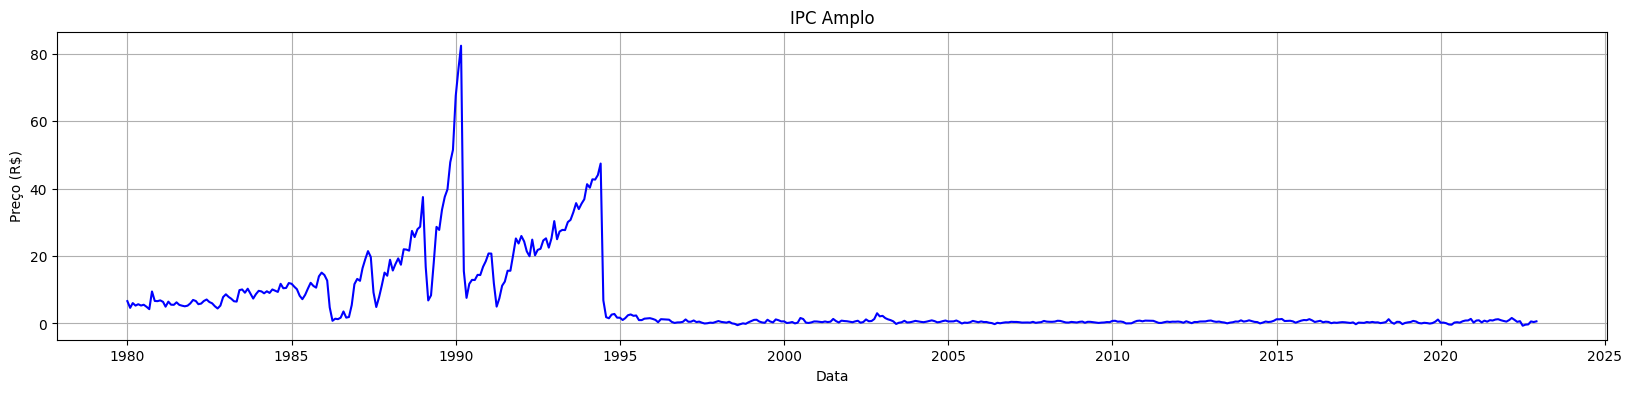

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 4))
plt.plot(ipc_df['referencia'], ipc_df['ipca_variacao'], label='IPC Amplo', color='blue')
# mostrar todos os anos
plt.title('IPC Amplo')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.grid()
plt.show()

## Estudando o dataset

In [7]:
print(f"Quantidade de meses: {len(ipc_df)}")
print(f"Quantidade de anos: {len(ipc_df) // 12}")
print(f"Split semestral: {len(ipc_df) // 6}")

Quantidade de meses: 516
Quantidade de anos: 43
Split semestral: 86


## Redes Recorrentes

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, LSTM, Dropout, SimpleRNN, GRU, Embedding)

neuronios = 32
epocas = 100
n_split = len(ipc_df) // 12 # 6 meses
print(f'N Split: {n_split}')

2024-10-10 12:14:12.336767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-10 12:14:12.347196: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-10 12:14:12.350199: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-10 12:14:12.358189: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-10 12:14:13.010250: W tensorflow/compiler/tf2

N Split: 43


In [9]:
from tensorflow.keras.layers import LSTM, Dense, SimpleRNN, Embedding, GRU
from tcn import TCN

def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i + n_steps])
    return np.array(X), np.array(y)

n_steps = 5 
X, y = create_sequences(ipc_df['ipca_variacao'].values, n_steps)

print(f"X shape: {X.shape} | y shape: {y.shape}") 

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X shape: (511, 5) | y shape: (511,)


### Recorrente Simples (Tanh)

In [10]:
tanh_model = Sequential([
    SimpleRNN(units=neuronios, activation='tanh', return_sequences=False, input_shape=(n_split, 1)),
    Dense(units=1)
])

# Compile the model
tanh_model.compile(optimizer='adam', loss='mean_squared_error')

/home/rafflezs-wsl/RedesNeurais-ICMC24/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### LSTM

In [11]:
lstm_model = Sequential([
    LSTM(units=neuronios, activation='tanh', return_sequences=False, input_shape=(n_split, 1)),
    Dense(units=1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

### GRU

In [12]:
gru_model = Sequential([
    GRU(units=neuronios, activation='tanh', return_sequences=False, input_shape=(n_split, 1)),
    Dense(units=1)
])

gru_model.compile(optimizer='adam', loss='mean_squared_error')

### TCN

In [13]:
from tcn import TCN

tcn_model = Sequential([
    TCN(input_shape=(n_split, 1)),
    Dense(units=1)
])

tcn_model.compile(optimizer='adam', loss='mean_squared_error')

/home/rafflezs-wsl/RedesNeurais-ICMC24/venv/lib/python3.12/site-packages/tcn/tcn.py:227: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


## Cross validation
### Time Series Split

In [14]:
class TimeSeriesSplit:
    def __init__(self, n_splits):
        self.n_splits = n_splits
    
    def get_n_splits(self):
        return self.n_splits
    
    def split(self, X):
        len_X = len(X)
        
        for i in range(self.n_splits, len_X, self.n_splits):
            train_indices = list(range(i))
            test_indices = [i]
            yield train_indices, test_indices

In [15]:
tscv = TimeSeriesSplit(n_splits=12)

print(f"Quantidade de splits: {tscv.get_n_splits()}")
for train_index, test_index in tscv.split(ipc_df):
    print(f"Train: {train_index} Test: {test_index}")

Quantidade de splits: 12
Train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] Test: [12]
Train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23] Test: [24]
Train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35] Test: [36]
Train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47] Test: [48]
Train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59] Test: [60]
Train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 

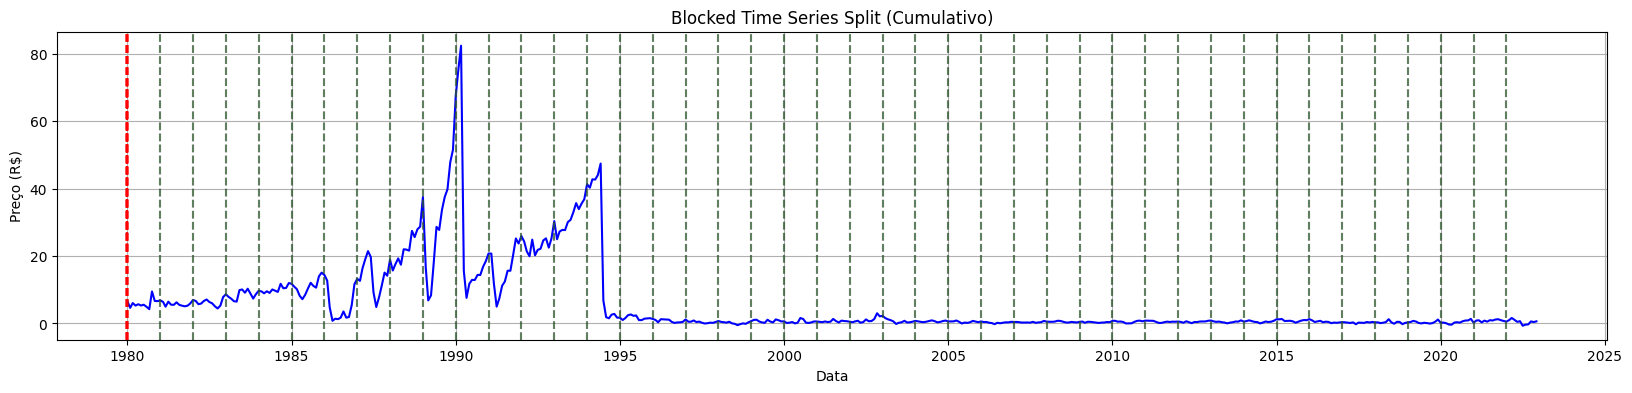

In [16]:
# plotando bloco de treino e teste 
plt.figure(figsize=(20, 4))
plt.plot(ipc_df['referencia'], ipc_df['ipca_variacao'], label='IPC Amplo', color='blue')
for train_idx, test_idx in tscv.split(ipc_df):
    plt.axvline(x=ipc_df['referencia'][train_idx[0]], color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=ipc_df['referencia'][test_idx[0]], color='purple', linestyle='--', alpha=0.5)
    plt.axvline(x=ipc_df['referencia'][test_idx[-1]], color='green', linestyle='--', alpha=0.5)
plt.title('Blocked Time Series Split (Cumulativo)')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.grid()
plt.show()

### Implementando o Blocked Time Series

In [17]:
class BlockedTimeSeriesSplit():
    def __init__(self, n_splits):
        self.n_splits = n_splits
    
    def get_n_splits(self):
        return self.n_splits
    
    def split(self, X):
        len_X = len(X)
        k_fold_size = len_X // self.n_splits
        indices = np.arange(len_X)

        margin = 0
        for i in range(self.n_splits):
            start = i * k_fold_size
            stop = start + k_fold_size
            mid = int(0.8 * (stop - start)) + start
            yield indices[start: mid], indices[mid + margin: stop]

In [18]:
bts = BlockedTimeSeriesSplit(n_splits=n_split)
for i, (train_index, test_index) in enumerate(bts.split(ipc_df)):
    print(f"Fold {i+1}:")
    print(f"Train: {train_index}")
    print(f"Test: {test_index}")

Fold 1:
Train: [0 1 2 3 4 5 6 7 8]
Test: [ 9 10 11]
Fold 2:
Train: [12 13 14 15 16 17 18 19 20]
Test: [21 22 23]
Fold 3:
Train: [24 25 26 27 28 29 30 31 32]
Test: [33 34 35]
Fold 4:
Train: [36 37 38 39 40 41 42 43 44]
Test: [45 46 47]
Fold 5:
Train: [48 49 50 51 52 53 54 55 56]
Test: [57 58 59]
Fold 6:
Train: [60 61 62 63 64 65 66 67 68]
Test: [69 70 71]
Fold 7:
Train: [72 73 74 75 76 77 78 79 80]
Test: [81 82 83]
Fold 8:
Train: [84 85 86 87 88 89 90 91 92]
Test: [93 94 95]
Fold 9:
Train: [ 96  97  98  99 100 101 102 103 104]
Test: [105 106 107]
Fold 10:
Train: [108 109 110 111 112 113 114 115 116]
Test: [117 118 119]
Fold 11:
Train: [120 121 122 123 124 125 126 127 128]
Test: [129 130 131]
Fold 12:
Train: [132 133 134 135 136 137 138 139 140]
Test: [141 142 143]
Fold 13:
Train: [144 145 146 147 148 149 150 151 152]
Test: [153 154 155]
Fold 14:
Train: [156 157 158 159 160 161 162 163 164]
Test: [165 166 167]
Fold 15:
Train: [168 169 170 171 172 173 174 175 176]
Test: [177 178 179]
Fold

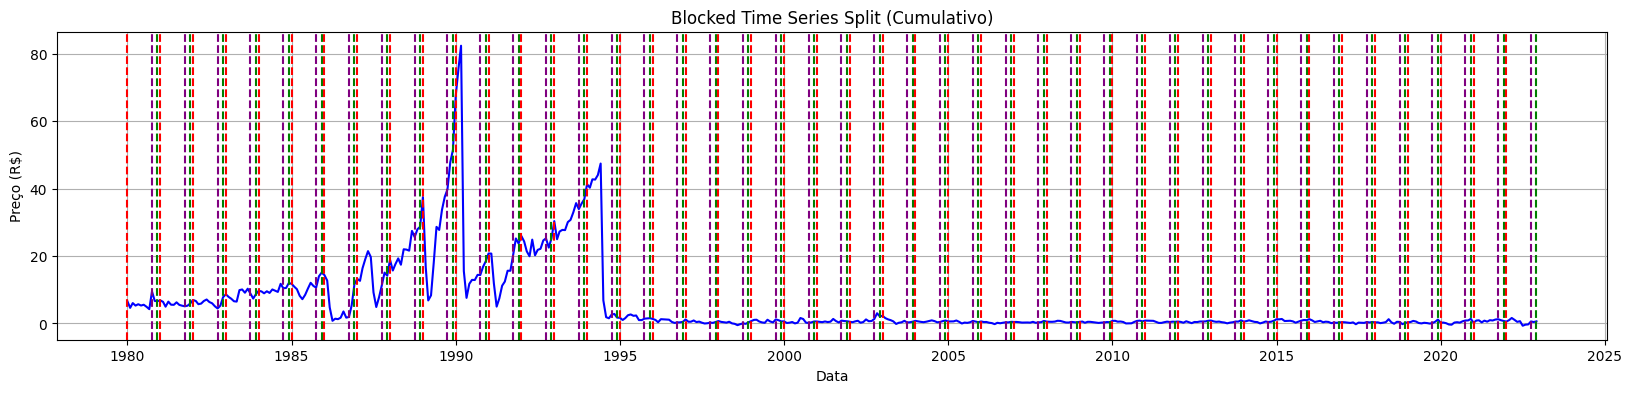

In [19]:
plt.figure(figsize=(20, 4))
plt.plot(ipc_df['referencia'], ipc_df['ipca_variacao'], label='IPC Amplo', color='blue')
for train_idx, test_idx in bts.split(ipc_df):
    plt.axvline(x=ipc_df['referencia'][train_idx[0]], color='red', linestyle='--')
    plt.axvline(x=ipc_df['referencia'][test_idx[0]], color='purple', linestyle='--')
    plt.axvline(x=ipc_df['referencia'][test_idx[-1]], color='green', linestyle='--')
plt.title('Blocked Time Series Split (Cumulativo)')
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.grid()
plt.show()

## Treinando e testando

In [20]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
from sklearn.metrics import root_mean_squared_error

def treinar(model, X, y, tscv, epocas=100):
    rmse = []
    model_history = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
        
        model_history = model.fit(X_train, y_train, epochs=epocas, verbose=0)
        
        y_pred = model.predict(X_test)
        
        rmse.append(np.sqrt(root_mean_squared_error(y_test, y_pred)))
    
    return {"Historic":model_history, "RMSE":rmse, "Media RMSE":np.mean(rmse), "STD RMSE":np.std(rmse)}


In [21]:
print("Treinando modelos...")

treino_sumario = {}

print("Treinando tanh (TSC)...")
treino_sumario["TANH_TSC"] = treinar(tanh_model, X, y, tscv, epocas=epocas)
print("Treinando LSTM (TSC)...")
treino_sumario["LSTM_TSC"] = treinar(lstm_model, X, y, tscv, epocas=epocas)
print("Treinando GRU (TSC)...")
treino_sumario["GRU_TSC"] = treinar(gru_model, X, y, tscv, epocas=epocas)
print("Treinando TCN (TSC)...")
treino_sumario["TCN_TSC"] = treinar(tcn_model, X, y, tscv, epocas=epocas)

print("Treinando tanh (BTS)...")
treino_sumario["TANH_BTS"] = treinar(tanh_model, X, y, bts, epocas=epocas)
print("Treinando LSTM (BTS)...")
treino_sumario["LSTM_BTS"] = treinar(lstm_model, X, y, bts, epocas=epocas)
print("Treinando GRU (BTS)...")
treino_sumario["GRU_BTS"] = treinar(gru_model, X, y, bts, epocas=epocas)
print("Treinando TCN (BTS)...")
treino_sumario["TCN_BTS"] = treinar(tcn_model, X, y, bts, epocas=epocas)

Treinando modelos...
Treinando tanh (TSC)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━

# Comparando os modelos

#### Time Series Split Cumulativa (Resultados)

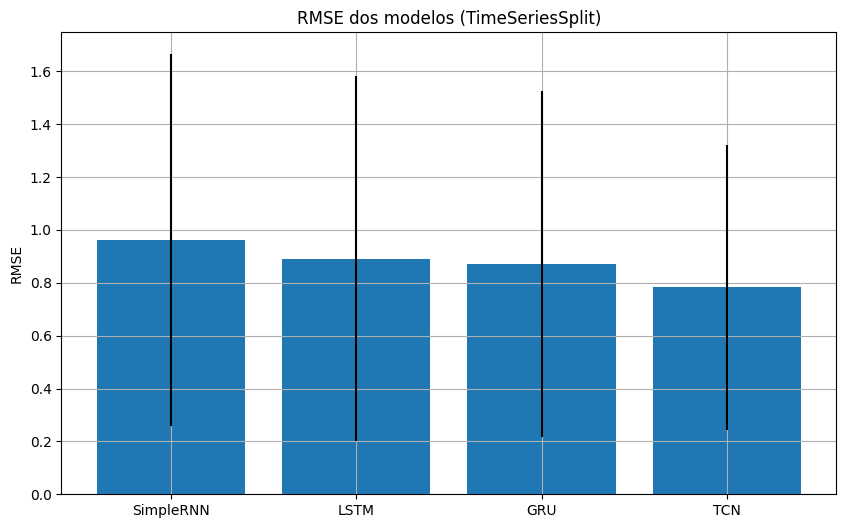

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(
    [
        'SimpleRNN', 
        'LSTM', 
        'GRU', 
        'TCN'
    ], [
        treino_sumario["TANH_TSC"]["Media RMSE"], 
        treino_sumario["LSTM_TSC"]["Media RMSE"], 
        treino_sumario["GRU_TSC"]["Media RMSE"], 
        treino_sumario["TCN_TSC"]["Media RMSE"]
    ], yerr=[
        treino_sumario["TANH_TSC"]["STD RMSE"], 
        treino_sumario["LSTM_TSC"]["STD RMSE"], 
        treino_sumario["GRU_TSC"]["STD RMSE"], 
        treino_sumario["TCN_TSC"]["STD RMSE"]
    ]
)

plt.title('RMSE dos modelos (TimeSeriesSplit)')
plt.ylabel('RMSE')
plt.grid()
plt.show()

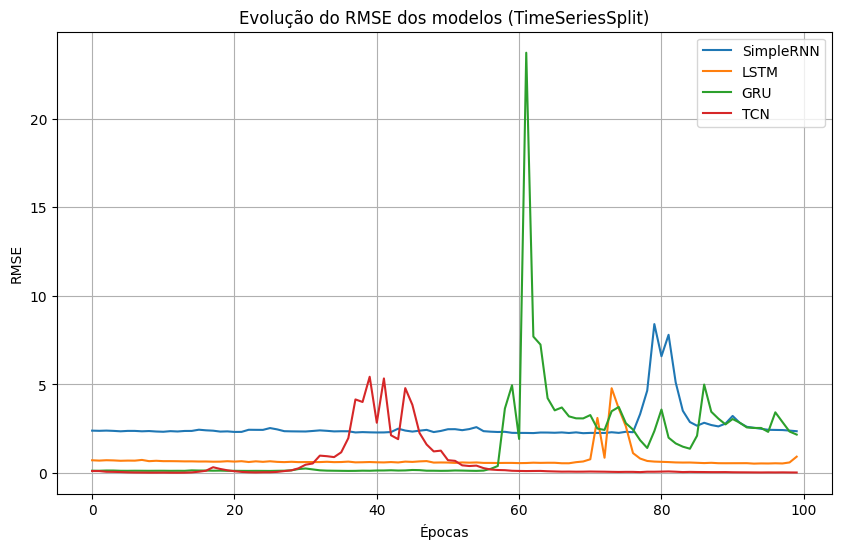

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(treino_sumario["TANH_TSC"]["Historic"].history['loss'], label='SimpleRNN')
plt.plot(treino_sumario["LSTM_TSC"]["Historic"].history['loss'], label='LSTM')
plt.plot(treino_sumario["GRU_TSC"]["Historic"].history['loss'], label='GRU')
plt.plot(treino_sumario["TCN_TSC"]["Historic"].history['loss'], label='TCN')
plt.title('Evolução do RMSE dos modelos (TimeSeriesSplit)')
plt.xlabel('Épocas')
plt.ylabel('RMSE')
plt.legend()
plt.grid()
plt.show()

#### Blocking Time Series Split (Resultados)

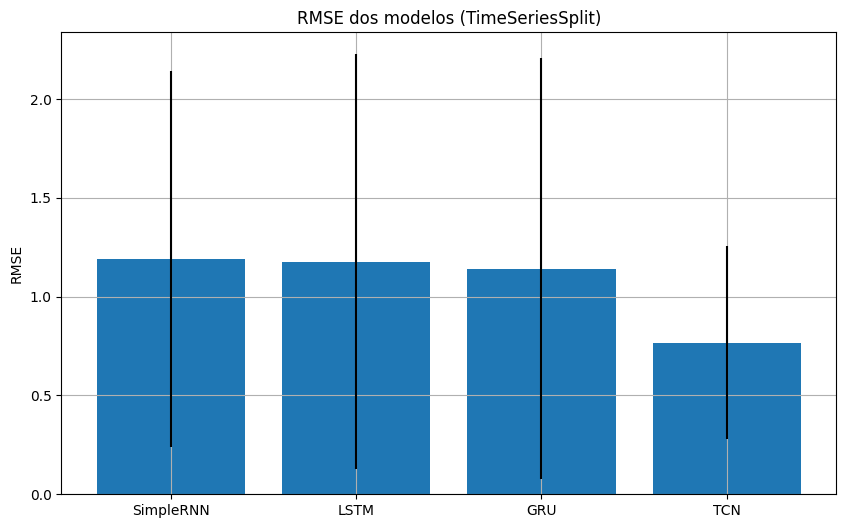

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(
    [
        'SimpleRNN', 
        'LSTM', 
        'GRU', 
        'TCN'
    ], [
        treino_sumario["TANH_BTS"]["Media RMSE"], 
        treino_sumario["LSTM_BTS"]["Media RMSE"], 
        treino_sumario["GRU_BTS"]["Media RMSE"], 
        treino_sumario["TCN_BTS"]["Media RMSE"]
    ], yerr=[
        treino_sumario["TANH_BTS"]["STD RMSE"], 
        treino_sumario["LSTM_BTS"]["STD RMSE"], 
        treino_sumario["GRU_BTS"]["STD RMSE"], 
        treino_sumario["TCN_BTS"]["STD RMSE"]
    ]
)

plt.title('RMSE dos modelos (TimeSeriesSplit)')
plt.ylabel('RMSE')
plt.grid()
plt.show()

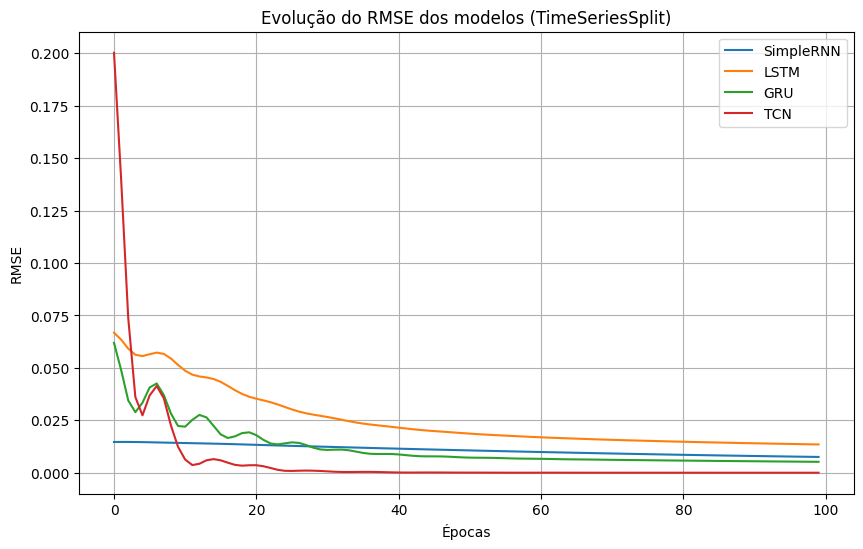

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(treino_sumario["TANH_BTS"]["Historic"].history['loss'], label='SimpleRNN')
plt.plot(treino_sumario["LSTM_BTS"]["Historic"].history['loss'], label='LSTM')
plt.plot(treino_sumario["GRU_BTS"]["Historic"].history['loss'], label='GRU')
plt.plot(treino_sumario["TCN_BTS"]["Historic"].history['loss'], label='TCN')
plt.title('Evolução do RMSE dos modelos (TimeSeriesSplit)')
plt.xlabel('Épocas')
plt.ylabel('RMSE')
plt.legend()
plt.grid()
plt.show()

# Tentando predição de 2023 com modelo de pilhas

In [43]:
stack_model = Sequential()
stack_model.add(LSTM(units=neuronios, activation='tanh', return_sequences=True, input_shape=(n_split, 1)))
stack_model.add(GRU(units=neuronios, activation='tanh', return_sequences=True))
stack_model.add(TCN(activation='relu', return_sequences=False, input_shape=(n_split, 1)))
stack_model.add(Dense(units=1))

stack_model.compile(optimizer='adam', loss='mean_squared_error')

/home/rafflezs-wsl/RedesNeurais-ICMC24/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
stack_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 43, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 43, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_6 (TCN)                     │ (None, 64)             │        97,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,841 (421.25 KB)

 Trainable params: 107,841 (421.25 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
stack_model_sumario = {}
stack_model_sumario["TSC"] = treinar(stack_model, X, y, tscv, epocas=epocas)
stack_model_sumario["BTS"] = treinar(stack_model, X, y, bts, epocas=epocas)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━

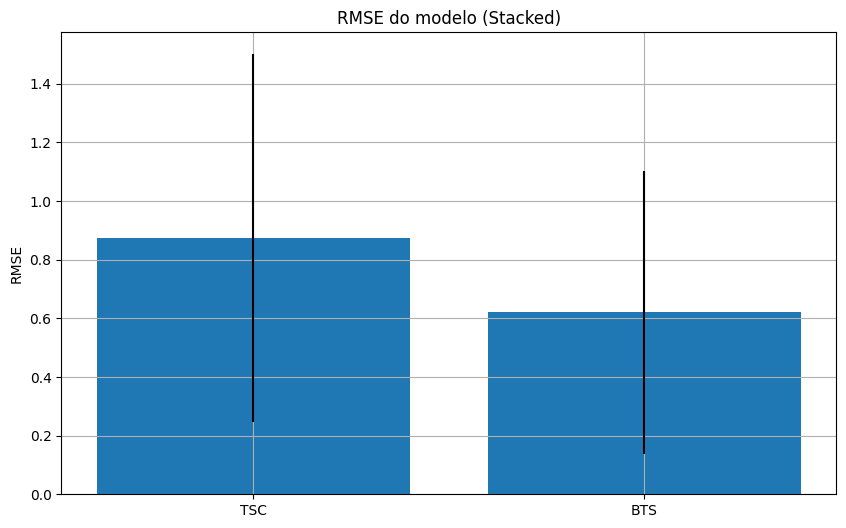

In [46]:
plt.figure(figsize=(10, 6))
plt.bar(
    [
        'TSC', 
        'BTS'
    ], [
        stack_model_sumario["TSC"]["Media RMSE"], 
        stack_model_sumario["BTS"]["Media RMSE"]
    ], yerr=[
        stack_model_sumario["TSC"]["STD RMSE"], 
        stack_model_sumario["BTS"]["STD RMSE"]
    ]
)

plt.title('RMSE do modelo (Stacked)')
plt.ylabel('RMSE')
plt.grid()
plt.show()

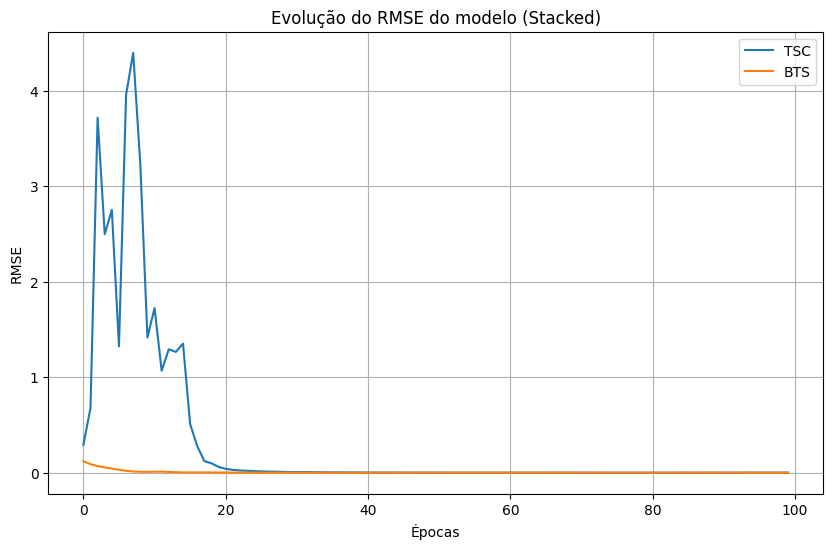

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(stack_model_sumario["TSC"]["Historic"].history['loss'], label='TSC')
plt.plot(stack_model_sumario["BTS"]["Historic"].history['loss'], label='BTS')
plt.title('Evolução do RMSE do modelo (Stacked)')
plt.xlabel('Épocas')
plt.ylabel('RMSE')
plt.legend()
plt.grid()
plt.show()